In [1]:
import pandas as pd
import numpy as np

In [2]:
# Cargar dataset limpio

df = pd.read_csv("C:\\Users\\eider\OneDrive - Mondragon Unibertsitatea\\RETOS_2BDTA\\RETO_7\\datos_prestamos_limpios.csv")


In [3]:
df[["Monto_Inicial", "Interes_Anual", "Duracion"]].describe()


,Monto_Inicial,Interes_Anual,Duracion
count,255347.000000,255347.000000,255347.000000
mean,127578.910542,0.134928,36.025894
std,70798.937401,0.066364,16.969330
min,7443.000000,0.020000,12.000000
25%,66156.000000,0.077700,24.000000
50%,127556.000000,0.134600,36.000000
75%,188985.000000,0.192500,48.000000
max,247545.540000,0.250000,60.000000


In [4]:
# Seleccionamos un préstamo representativo (mediana)

prestamo = df.loc[
    (df["Monto_Inicial"] - df["Monto_Inicial"].median()).abs().idxmin()
]

capital = prestamo["Monto_Inicial"]
interes_anual = prestamo["Interes_Anual"]
n_periodos = int(prestamo["Duracion"])

print("Préstamo seleccionado (representativo – mediana):")
print(f".Capital inicial: {capital:,.2f} €")
print(f".Interés anual: {interes_anual * 100:.2f} %")
print(f".Duración: {n_periodos} meses")



Préstamo seleccionado (representativo – mediana):
.Capital inicial: 127,556.00 €
.Interés anual: 3.80 %
.Duración: 48 meses


Para llevar a cabo la simulación, se ha seleccionado un préstamo representativo del conjunto de datos, definido como aquel cuyo monto inicial es el más cercano a la mediana de la variable Monto_Inicial. Esta elección permite trabajar con un caso realista y típico del dataset, evitando valores extremos que podrían sesgar la comparación entre sistemas.

Del préstamo seleccionado se extraen las variables necesarias para la simulación:

Capital inicial (Monto_Inicial)

Tipo de interés anual (Interes_Anual), expresado en tanto por uno

Duración del préstamo (Duracion), en meses

Estas variables constituyen la base para la simulación de los distintos sistemas de amortización.

Funciones de amortización

In [5]:
# Sistema Francés

def amortizacion_frances(capital, interes_anual, n_periodos):
    i = interes_anual / 12
    cuota = capital * (i * (1 + i)**n_periodos) / ((1 + i)**n_periodos - 1)

    saldo = capital
    tabla = []

    for t in range(1, n_periodos + 1):
        intereses = saldo * i
        amortizacion = cuota - intereses
        saldo -= amortizacion

        tabla.append([t, cuota, intereses, amortizacion, saldo])

    return pd.DataFrame(
        tabla,
        columns=["Periodo", "Cuota", "Intereses", "Amortizacion", "Saldo_pendiente"]
    )


In [6]:
# Sistema Alemán

def amortizacion_aleman(capital, interes_anual, n_periodos):
    i = interes_anual / 12
    amortizacion_constante = capital / n_periodos

    saldo = capital
    tabla = []

    for t in range(1, n_periodos + 1):
        intereses = saldo * i
        cuota = amortizacion_constante + intereses
        saldo -= amortizacion_constante

        tabla.append([t, cuota, intereses, amortizacion_constante, saldo])

    return pd.DataFrame(
        tabla,
        columns=["Periodo", "Cuota", "Intereses", "Amortizacion", "Saldo_pendiente"]
    )


In [7]:
# Tablas de amortización

frances = amortizacion_frances(capital, interes_anual, n_periodos)
aleman = amortizacion_aleman(capital, interes_anual, n_periodos)

In [8]:
# Cuota mensual del sistema elegido (francés)
cuota = frances["Cuota"].iloc[0]


In [9]:
# Validación: el saldo final debe ser aproximadamente 0

saldo_final_frances = frances["Saldo_pendiente"].iloc[-1]
saldo_final_aleman = aleman["Saldo_pendiente"].iloc[-1]

print("VALIDACIÓN DEL SALDO FINAL")
print(f"Saldo final (Sistema Francés): {saldo_final_frances:.6f} €")
print(f"Saldo final (Sistema Alemán): {saldo_final_aleman:.6f} €")


VALIDACIÓN DEL SALDO FINAL
Saldo final (Sistema Francés): 0.000000 €
Saldo final (Sistema Alemán): -0.000000 €


(Se valida que el saldo pendiente al final del préstamo sea aproximadamente cero, lo que confirma que el préstamo queda completamente amortizado y que el modelo está correctamente implementado). El saldo final es prácticamente cero en ambos sistemas, lo que valida correctamente las tablas de amortización. El pequeño valor negativo observado en el sistema alemán se debe a errores de redondeo numérico propios del cálculo en punto flotante.

In [10]:
# Comparación de intereses totales

intereses_frances = frances["Intereses"].sum()
intereses_aleman = aleman["Intereses"].sum()

print("Intereses totales pagados durante el préstamo:")
print(f".Sistema Francés: {intereses_frances:,.2f} €")
print(f".Sistema Alemán: {intereses_aleman:,.2f} €")



Intereses totales pagados durante el préstamo:
.Sistema Francés: 10,141.22 €
.Sistema Alemán: 9,896.22 €


Comparación de cuotas

In [11]:
frances[["Periodo", "Cuota"]].head()

,Periodo,Cuota
0,1,2868.692062
1,2,2868.692062
2,3,2868.692062
3,4,2868.692062
4,5,2868.692062


In [12]:
aleman[["Periodo", "Cuota"]].head()

,Periodo,Cuota
0,1,3061.344000
1,2,3052.928847
2,3,3044.513694
3,4,3036.098542
4,5,3027.683389


La comparación de las primeras cuotas permite observar claramente las diferencias entre ambos sistemas: en el sistema francés la cuota permanece constante durante toda la vida del préstamo, mientras que en el sistema alemán la cuota disminuye progresivamente debido a la reducción de los intereses sobre un capital pendiente cada vez menor

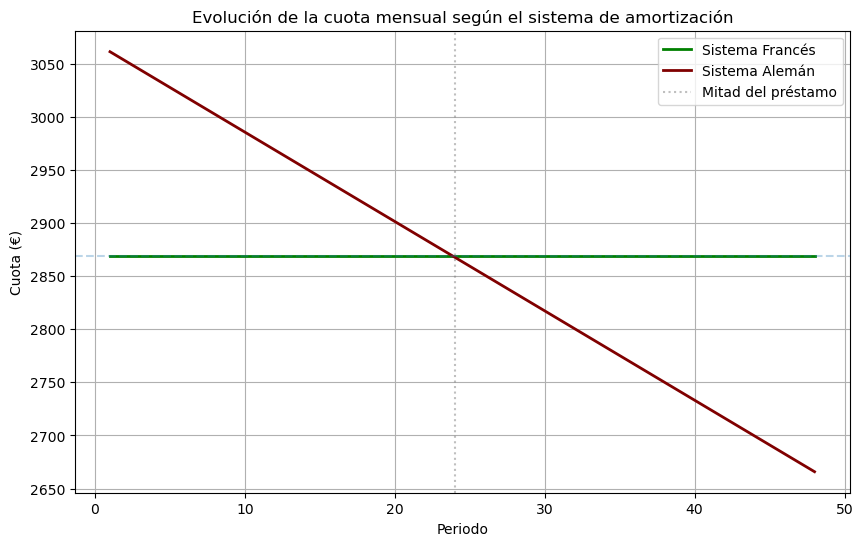

In [13]:
# Comparación de la evolución de la cuota mensual bajo los sistemas de amortización francés y alemán

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(frances["Periodo"], frances["Cuota"],
         label="Sistema Francés", color="green", linewidth=2)

plt.plot(aleman["Periodo"], aleman["Cuota"],
         label="Sistema Alemán", color="maroon", linewidth=2)

# Líneas de referencia
plt.axhline(frances["Cuota"].iloc[0], linestyle="--", alpha=0.3)
plt.axvline(x=n_periodos//2, linestyle=":", color="gray", alpha=0.5,
            label="Mitad del préstamo")

plt.xlabel("Periodo")
plt.ylabel("Cuota (€)")
plt.title("Evolución de la cuota mensual según el sistema de amortización")
plt.legend()
plt.grid(True)

plt.show()


Evolución de la cuota mensual según el sistema de amortización.
El gráfico compara el comportamiento de la cuota mensual para un préstamo representativo bajo los sistemas francés y alemán. El sistema francés se caracteriza por una cuota constante
a lo largo de toda la vida del préstamo, lo que aporta estabilidad y previsibilidad.
Por el contrario, el sistema alemán presenta cuotas inicialmente más elevadas que disminuyen progresivamente, reduciendo el coste financiero total, pero aumentando el esfuerzo inicial.
Esta visualización apoya la elección del sistema francés para los análisis posteriores.



El objetivo de este apartado es simular la amortización de un préstamo bajo diferentes sistemas, concretamente el sistema francés y el sistema alemán, con el fin de analizar sus características principales y seleccionar el método más adecuado para continuar el resto del proceso analítico.

Simulación del sistema francés

En el sistema francés, la cuota mensual es constante durante toda la vida del préstamo. La simulación muestra que, en los primeros periodos, una mayor parte de la cuota se destina al pago de intereses, mientras que la amortización del capital es reducida. Con el paso del tiempo, esta relación se invierte: los intereses disminuyen y la amortización aumenta, manteniéndose siempre una cuota fija.

Este sistema ofrece una mayor estabilidad en los pagos, lo que facilita la planificación financiera del prestatario.

Simulación del sistema alemán

En el sistema alemán, la amortización del capital es constante en cada periodo, lo que provoca que las cuotas sean más elevadas al inicio del préstamo y vayan disminuyendo progresivamente a lo largo del tiempo. La simulación refleja un mayor esfuerzo financiero en los primeros meses, compensado por cuotas más reducidas en los últimos periodos.

Como consecuencia de una amortización más rápida del capital, el importe total de intereses pagados resulta inferior al del sistema francés.

Comparación de resultados y análisis gráfico

A partir de los cuadros de amortización simulados, se han comparado tanto el coste total en intereses como la evolución de las cuotas mensuales. La representación gráfica de las cuotas confirma claramente que:

El sistema francés presenta una cuota constante.

El sistema alemán muestra una cuota decreciente a lo largo del tiempo.

Además, el cálculo de los intereses totales pone de manifiesto que el sistema alemán supone un menor coste financiero global, mientras que el sistema francés prioriza la estabilidad de pagos.


Selección del sistema para continuar el análisis

Tras la simulación y comparación de ambos sistemas, se decide continuar el resto del análisis utilizando el sistema francés. Esta elección se justifica por los siguientes motivos:

Es el sistema más utilizado en la práctica bancaria, lo que facilita la interpretación de los resultados.

La cuota constante simplifica el cálculo del valor presente de las cuotas pendientes en el siguiente objetivo.

Permite una mejor integración con el análisis del riesgo de impago, al mantener una carga financiera estable a lo largo del tiempo.

Dado que el objetivo del estudio es continuar con análisis posteriores (valor presente y modelización del riesgo de impago), se selecciona el sistema francés por su estabilidad en las cuotas y su mayor representatividad en el mercado financiero real.

Este análisis sienta la base para los siguientes objetivos, en los que se trabajará exclusivamente con el sistema francés.